# 딥러닝 프로그래밍 수행 평가 (3307 류현정)
<b>주제<b>: DNA 서열 기반 프로모터(Promoter) 예측 딥러닝 모델 개발

=> DAN 서열이 주어졌을 때, 해당 서열이 프로코터 영역인지 아닌지를 분류하는 이진 분류 문제

### 라이브러리 생성

Data link = https://www.kaggle.com/datasets/stefanost/gene-promoter-sequences/code

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

### 데이터 전처리

In [2]:
data = pd.read_csv('dataset/promoters.data',header=None)
data.head()

,0,1,2
0,+,S10,\t\ttactagcaatacgcttgcgttcggtggttaagtatgtataat...
1,+,AMPC,\t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaat...
2,+,AROH,\t\tgtactagagaactagtgcattagcttatttttttgttatcat...
3,+,DEOP2,\taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaa...
4,+,LEU1_TRNA,\ttcgataattaactattgacgaaaagctgaaaaccactagaatgc...


In [3]:
data.columns = ['label', 'id', 'sequence']
data.head()

,label,id,sequence
0,+,S10,\t\ttactagcaatacgcttgcgttcggtggttaagtatgtataat...
1,+,AMPC,\t\ttgctatcctgacagttgtcacgctgattggtgtcgttacaat...
2,+,AROH,\t\tgtactagagaactagtgcattagcttatttttttgttatcat...
3,+,DEOP2,\taattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaa...
4,+,LEU1_TRNA,\ttcgataattaactattgacgaaaagctgaaaaccactagaatgc...


In [4]:
data['sequence'] = data['sequence'].str.replace('\t', '').str.strip()
data.head()

,label,id,sequence
0,+,S10,tactagcaatacgcttgcgttcggtggttaagtatgtataatgcgc...
1,+,AMPC,tgctatcctgacagttgtcacgctgattggtgtcgttacaatctaa...
2,+,AROH,gtactagagaactagtgcattagcttatttttttgttatcatgcta...
3,+,DEOP2,aattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaata...
4,+,LEU1_TRNA,tcgataattaactattgacgaaaagctgaaaaccactagaatgcgc...


In [5]:
data['label'] = data['label'].map({'+': 1, '-': 0})
data.head()

,label,id,sequence
0,1,S10,tactagcaatacgcttgcgttcggtggttaagtatgtataatgcgc...
1,1,AMPC,tgctatcctgacagttgtcacgctgattggtgtcgttacaatctaa...
2,1,AROH,gtactagagaactagtgcattagcttatttttttgttatcatgcta...
3,1,DEOP2,aattgtgatgtgtatcgaagtgtgttgcggagtagatgttagaata...
4,1,LEU1_TRNA,tcgataattaactattgacgaaaagctgaaaaccactagaatgcgc...


In [6]:
data['label']

0      1
1      1
2      1
3      1
4      1
      ..
101    0
102    0
103    0
104    0
105    0
Name: label, Length: 106, dtype: int64

In [7]:
# DNA 염기 서열을 원-핫 인코딩하는 함수 정의
def one_hot_encoding(sequence):
    mapping = {'a': [1,0,0,0], 't': [0,1,0,0], 'c': [0,0,1,0], 'g': [0,0,0,1]}
    # 계획서에 맞게 염기 문자열을 2차원 배열(57, 4) 형태로 변환
    encoded = [mapping[base] for base in sequence.lower() if base in mapping]
    return np.array(encoded)

# 전체 데이터셋 원-핫 인코딩 적용
X = np.array([one_hot_encoding(seq) for seq in data['sequence']])
y = data['label'].values

# 데이터 분할 계획 (Train : Validation : Test = 7 : 2 : 1)
# 1단계: Train(70%)과 임시 데이터(30%) 분할
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 2단계: 임시 데이터(30%)를 다시 Validation(20%)과 Test(10%)로 분할 (30% 중 2/3가 20%가 됨)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp)

print(f"Train 크기: {X_train.shape}, Validation 크기: {X_val.shape}, Test 크기: {X_test.shape}")

Train 크기: (74, 57, 4), Validation 크기: (21, 57, 4), Test 크기: (11, 57, 4)


In [8]:
# 계획서 기반 Conv1D 이진 분류 모델 설계
model = Sequential([
    # 입력층 & Conv1D Layer: 서열 내 지역적 패턴(모티프) 추출
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(57, 4)),
    
    # MaxPooling Layer: 특징 압축 및 노이즈 제거
    MaxPooling1D(pool_size=2),
    
    # Flatten Layer: 1차원 벡터 변환
    Flatten(),
    
    # Dense Layer: 비선형 조합 학습 (과적합 방지를 위해 Dropout 추가 가능)
    Dense(64, activation='relu'),
    Dropout(0.3), 
    
    # Output Layer: Sigmoid 함수 (0~1 확률 출력하여 이진 분류)
    Dense(1, activation='sigmoid')
])

# 모델 컴파일 (이진 분류이므로 binary_crossentropy 사용)
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 55, 32)            416       
                                                                 
 max_pooling1d (MaxPooling1D  (None, 27, 32)           0         
 )                                                               
                                                                 
 flatten (Flatten)           (None, 864)               0         
                                                                 
 dense (Dense)               (None, 64)                55360     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                        

In [19]:
# 모델 학습 진행
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/100
10/10 [==============================] - 0s 13ms/step - loss: 1.0321 - accuracy: 0.7432 - val_loss: 0.5953 - val_accuracy: 0.8095
Epoch 2/100
10/10 [==============================] - 0s 11ms/step - loss: 0.5475 - accuracy: 0.7838 - val_loss: 0.2848 - val_accuracy: 0.9048
Epoch 3/100
10/10 [==============================] - 0s 10ms/step - loss: 0.3927 - accuracy: 0.8514 - val_loss: 0.4063 - val_accuracy: 0.7619
Epoch 4/100
10/10 [==============================] - 0s 11ms/step - loss: 0.3373 - accuracy: 0.8716 - val_loss: 0.2838 - val_accuracy: 0.8571
Epoch 5/100
10/10 [==============================] - 0s 10ms/step - loss: 0.2420 - accuracy: 0.9189 - val_loss: 0.2839 - val_accuracy: 0.9048
Epoch 6/100
10/10 [==============================] - 0s 11ms/step - loss: 0.2219 - accuracy: 0.9459 - val_loss: 0.3000 - val_accuracy: 0.8571
Epoch 7/100
10/10 [==============================] - 0s 10ms/step - loss: 0.1614 - accuracy: 0.9392 - val_loss: 0.2627 - val_accuracy: 0.8571
Epoch 

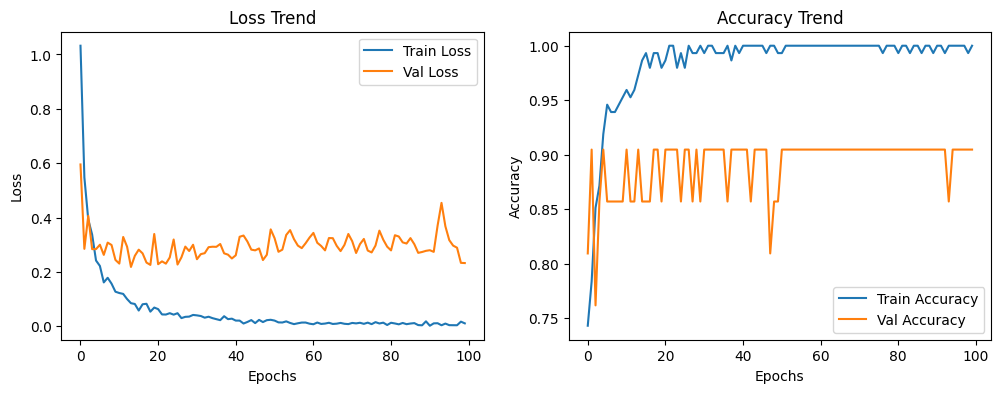

1/1 [==============================] - 0s 24ms/step
최종 결과 분석 (정량적 목표 달성 여부)
최종 Test Accuracy: 0.8182 (목표: 85% 이상 -> 미달)
최종 Test F1-Score: 0.8000 (목표: 0.85 이상 -> 미달)
              precision    recall  f1-score   support

Non-Promoter       0.83      0.83      0.83         6
    Promoter       0.80      0.80      0.80         5

    accuracy                           0.82        11
   macro avg       0.82      0.82      0.82        11
weighted avg       0.82      0.82      0.82        11



In [21]:
# 1. 학습 과정 시각화 (Loss & Accuracy)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Trend')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Trend')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# 2. 테스트 데이터셋 최종 평가 및 결과 산출
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # 시그모이드 확률값을 0 또는 1로 변환

final_accuracy = accuracy_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)

print("="*40)
print(f"최종 결과 분석 (정량적 목표 달성 여부)")
print("="*40)
print(f"최종 Test Accuracy: {final_accuracy:.4f} (목표: 85% 이상 -> {'달성' if final_accuracy >= 0.85 else '미달'})")
print(f"최종 Test F1-Score: {final_f1:.4f} (목표: 0.85 이상 -> {'달성' if final_f1 >= 0.85 else '미달'})")
print("="*40)

# 상세 리포트 출력
print(classification_report(y_test, y_pred, target_names=['Non-Promoter', 'Promoter']))

In [11]:
# [8번 셀 수정안] 과적합 방지를 위한 모델 구조 개선
model = Sequential([
    # 필터 수를 32개에서 16개로 줄여 모델을 가볍게 만듭니다.
    Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(57, 4)),
    MaxPooling1D(pool_size=2),
    
    Flatten(),
    
    # Dense 층의 노드 수도 줄이고, Dropout 비율을 0.3에서 0.5로 상향합니다.
    Dense(32, activation='relu'),
    Dropout(0.5), 
    
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_1 (Conv1D)           (None, 55, 16)            208       
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 27, 16)           0         
 1D)                                                             
                                                                 
 flatten_1 (Flatten)         (None, 432)               0         
                                                                 
 dense_2 (Dense)             (None, 32)                13856     
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_3 (Dense)             (None, 1)                 33        
                                                      

In [22]:
# 9번 셀 학습 시 batch_size를 8 또는 32로 변경해보기
history = model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_val, y_val), verbose=1)

Epoch 1/100
19/19 [==============================] - 0s 11ms/step - loss: 0.0129 - accuracy: 1.0000 - val_loss: 0.4445 - val_accuracy: 0.8571
Epoch 2/100
19/19 [==============================] - 0s 8ms/step - loss: 0.0066 - accuracy: 1.0000 - val_loss: 0.3669 - val_accuracy: 0.9048
Epoch 3/100
19/19 [==============================] - 0s 8ms/step - loss: 0.0108 - accuracy: 1.0000 - val_loss: 0.2795 - val_accuracy: 0.9048
Epoch 4/100
19/19 [==============================] - 0s 9ms/step - loss: 0.0093 - accuracy: 1.0000 - val_loss: 0.4531 - val_accuracy: 0.8571
Epoch 5/100
19/19 [==============================] - 0s 9ms/step - loss: 0.0049 - accuracy: 1.0000 - val_loss: 0.3374 - val_accuracy: 0.9048
Epoch 6/100
19/19 [==============================] - 0s 9ms/step - loss: 0.0113 - accuracy: 1.0000 - val_loss: 0.2661 - val_accuracy: 0.9048
Epoch 7/100
19/19 [==============================] - 0s 10ms/step - loss: 0.0117 - accuracy: 0.9932 - val_loss: 0.2594 - val_accuracy: 0.9048
Epoch 8/100

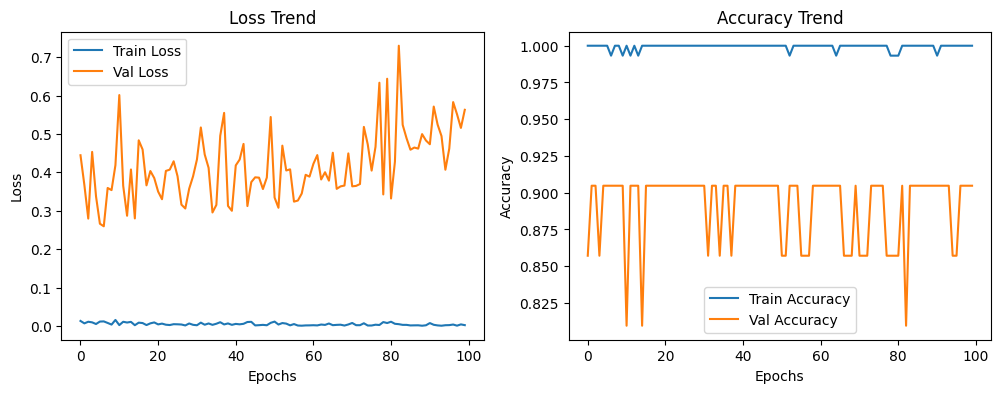

1/1 [==============================] - 0s 23ms/step
최종 결과 분석 (정량적 목표 달성 여부)
최종 Test Accuracy: 0.8182 (목표: 85% 이상 -> 미달)
최종 Test F1-Score: 0.8000 (목표: 0.85 이상 -> 미달)
              precision    recall  f1-score   support

Non-Promoter       0.83      0.83      0.83         6
    Promoter       0.80      0.80      0.80         5

    accuracy                           0.82        11
   macro avg       0.82      0.82      0.82        11
weighted avg       0.82      0.82      0.82        11



In [23]:
# 1. 학습 과정 시각화 (Loss & Accuracy)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Trend')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Trend')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# 2. 테스트 데이터셋 최종 평가 및 결과 산출
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) # 시그모이드 확률값을 0 또는 1로 변환

final_accuracy = accuracy_score(y_test, y_pred)
final_f1 = f1_score(y_test, y_pred)

print("="*40)
print(f"최종 결과 분석 (정량적 목표 달성 여부)")
print("="*40)
print(f"최종 Test Accuracy: {final_accuracy:.4f} (목표: 85% 이상 -> {'달성' if final_accuracy >= 0.85 else '미달'})")
print(f"최종 Test F1-Score: {final_f1:.4f} (목표: 0.85 이상 -> {'달성' if final_f1 >= 0.85 else '미달'})")
print("="*40)

# 상세 리포트 출력
print(classification_report(y_test, y_pred, target_names=['Non-Promoter', 'Promoter']))

## 데이터 증강 이후 학습

In [15]:
# [수정된 데이터 전처리 및 증강 파트]

# 1. 원-핫 인코딩 함수 (기존과 동일)
def one_hot_encoding(sequence):
    mapping = {'a': [1,0,0,0], 't': [0,1,0,0], 'c': [0,0,1,0], 'g': [0,0,0,1]}
    encoded = [mapping[base] for base in sequence.lower() if base in mapping]
    return np.array(encoded)

# 2. DNA 상보적 반전(Reverse Complement) 증강 함수 정의
def augment_reverse_complement(sequence):
    complement = {'a': 't', 't': 'a', 'c': 'g', 'g': 'c'}
    # 서열을 뒤집고(reverse) 상보적 염기(complement)로 변환
    rev_seq = "".join([complement[base] for base in sequence.lower()[::-1] if base in complement])
    return rev_seq

# 3. 기본 데이터 분할 (먼저 7:2:1로 나눈 후 Train만 증강)
X_raw = data['sequence'].values
y_raw = data['label'].values

X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(X_raw, y_raw, test_size=0.3, random_state=42, stratify=y_raw)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp)

# 4. Train 데이터에만 증강 적용
aug_X_train = []
aug_y_train = []

for seq, label in zip(X_train_raw, y_train_raw):
    # 원본 데이터 추가
    aug_X_train.append(one_hot_encoding(seq))
    aug_y_train.append(label)
    
    # 상보적 반전 증강 데이터 추가 (데이터 2배 확충)
    augmented_seq = augment_reverse_complement(seq)
    aug_X_train.append(one_hot_encoding(augmented_seq))
    aug_y_train.append(label)

# 최종 배열 변환
X_train = np.array(aug_X_train)
y_train = np.array(aug_y_train)

# Validation과 Test는 증강 없이 원-핫 인코딩만 진행
X_val = np.array([one_hot_encoding(seq) for seq in X_val_raw])
y_val = y_val_raw
X_test = np.array([one_hot_encoding(seq) for seq in X_test_raw])
y_test = y_test_raw

print(f"증강 후 Train 크기: {X_train.shape} (기존 74개 -> 148개로 증가)")
print(f"Validation 크기: {X_val.shape}, Test 크기: {X_test.shape}")

증강 후 Train 크기: (148, 57, 4) (기존 74개 -> 148개로 증가)
Validation 크기: (21, 57, 4), Test 크기: (11, 57, 4)


In [27]:
# [버전 1] 기획서 원본 모델 구조 정의
model_v1 = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(57, 4)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3), 
    Dense(1, activation='sigmoid')
])

model_v1.summary()

model_v1.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

history_v1 = model_v1.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_7 (Conv1D)           (None, 55, 32)            416       
                                                                 
 max_pooling1d_7 (MaxPooling  (None, 27, 32)           0         
 1D)                                                             
                                                                 
 flatten_7 (Flatten)         (None, 864)               0         
                                                                 
 dense_14 (Dense)            (None, 64)                55360     
                                                                 
 dropout_7 (Dropout)         (None, 64)                0         
                                                                 
 dense_15 (Dense)            (None, 1)                 65        
                                                      

In [17]:
# [버전 2] 과적합 방지 개선 모델 구조 정의
model_v2 = Sequential([
    Conv1D(filters=16, kernel_size=3, activation='relu', input_shape=(57, 4)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dropout(0.5), 
    Dense(1, activation='sigmoid')
])

model_v2.compile(optimizer='adam',
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

print("\n--- 버전 2: 개선된 모델 학습 시작 ---")
# 배치 사이즈를 8로 조정하여 소량 데이터셋 학습 밀도를 높임
history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=8,
    validation_data=(X_val, y_val),
    verbose=1
)


--- 버전 2: 개선된 모델 학습 시작 ---
Epoch 1/50
19/19 [==============================] - 1s 19ms/step - loss: 0.6922 - accuracy: 0.5473 - val_loss: 0.6882 - val_accuracy: 0.6667
Epoch 2/50
19/19 [==============================] - 0s 9ms/step - loss: 0.6813 - accuracy: 0.5946 - val_loss: 0.6424 - val_accuracy: 0.7619
Epoch 3/50
19/19 [==============================] - 0s 8ms/step - loss: 0.5947 - accuracy: 0.6351 - val_loss: 0.6324 - val_accuracy: 0.6667
Epoch 4/50
19/19 [==============================] - 0s 9ms/step - loss: 0.5397 - accuracy: 0.7568 - val_loss: 0.6065 - val_accuracy: 0.6667
Epoch 5/50
19/19 [==============================] - 0s 8ms/step - loss: 0.4957 - accuracy: 0.7905 - val_loss: 0.5544 - val_accuracy: 0.7619
Epoch 6/50
19/19 [==============================] - 0s 11ms/step - loss: 0.4720 - accuracy: 0.8108 - val_loss: 0.5498 - val_accuracy: 0.7619
Epoch 7/50
19/19 [==============================] - 0s 10ms/step - loss: 0.4496 - accuracy: 0.7635 - val_loss: 0.5277 - val_accura

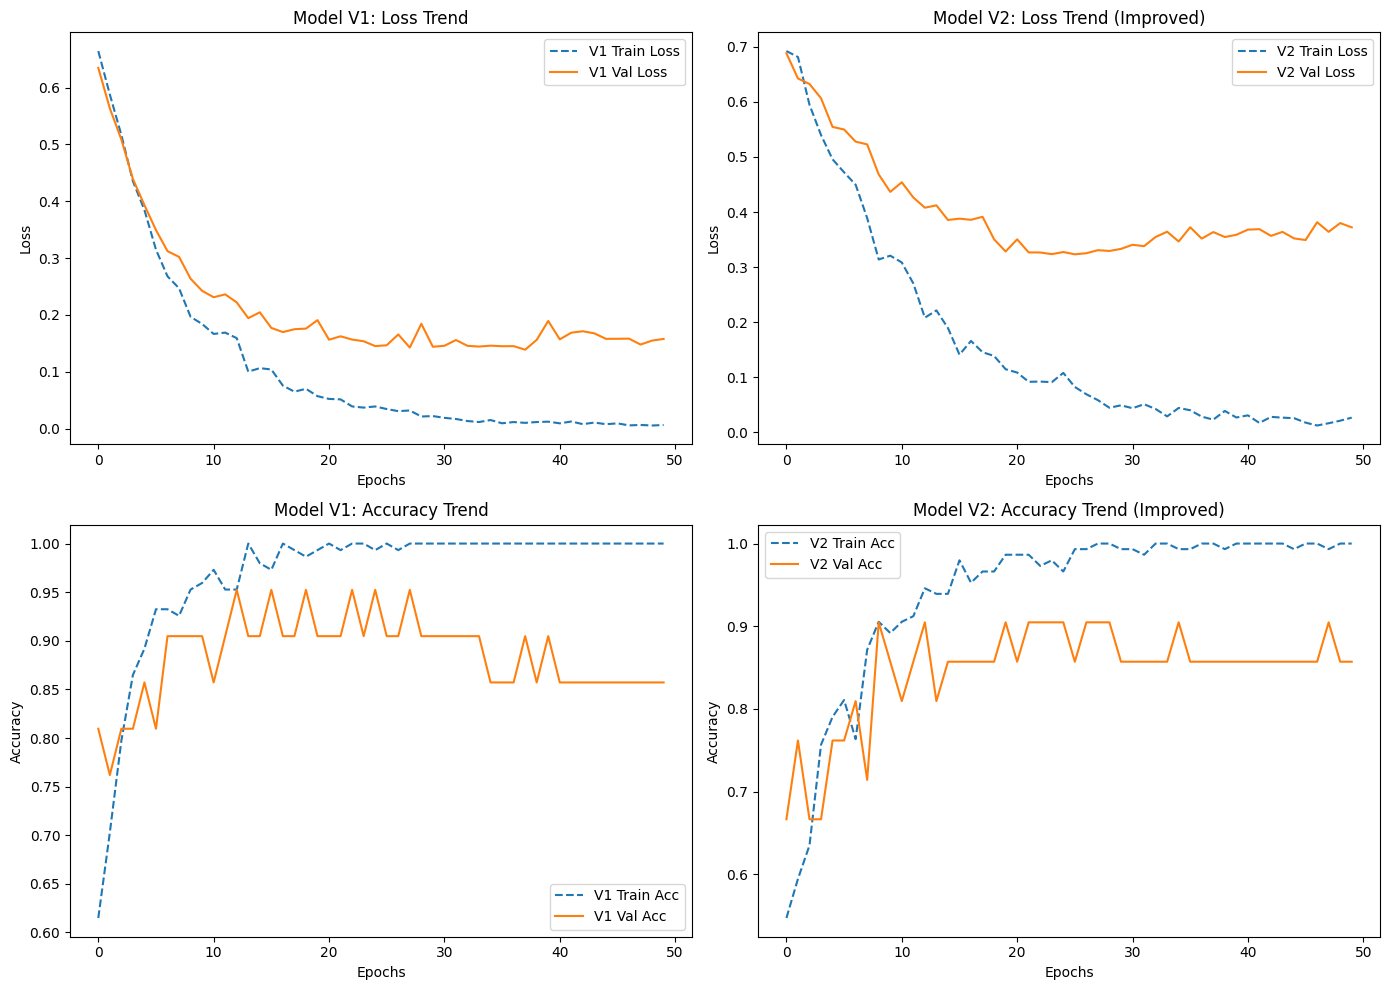

 버전 1 (기획서 원본 구조 + 증강) 최종 결과 분석
Test Accuracy : 0.9091 (목표 85% 이상 -> 공략 달성 🎉)
Test F1-Score : 0.8889 (목표 0.85 이상 -> 공략 달성 🎉)
--------------------------------------------------
              precision    recall  f1-score   support

Non-Promoter       0.86      1.00      0.92         6
    Promoter       1.00      0.80      0.89         5

    accuracy                           0.91        11
   macro avg       0.93      0.90      0.91        11
weighted avg       0.92      0.91      0.91        11



 버전 2 (개선된 구조 + 증강) 최종 결과 분석
Test Accuracy : 0.7273 (목표 85% 이상 -> 미달 😭)
Test F1-Score : 0.6667 (목표 0.85 이상 -> 미달 😭)
--------------------------------------------------
              precision    recall  f1-score   support

Non-Promoter       0.71      0.83      0.77         6
    Promoter       0.75      0.60      0.67         5

    accuracy                           0.73        11
   macro avg       0.73      0.72      0.72        11
weighted avg       0.73      0.73      0.72        11




In [18]:
# 1. 두 모델의 학습 추이 비교 시각화
plt.figure(figsize=(14, 10))

# Loss 비교 그래프
plt.subplot(2, 2, 1)
plt.plot(history_v1.history['loss'], label='V1 Train Loss', linestyle='--')
plt.plot(history_v1.history['val_loss'], label='V1 Val Loss')
plt.title('Model V1: Loss Trend')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(history_v2.history['loss'], label='V2 Train Loss', linestyle='--')
plt.plot(history_v2.history['val_loss'], label='V2 Val Loss')
plt.title('Model V2: Loss Trend (Improved)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy 비교 그래프
plt.subplot(2, 2, 3)
plt.plot(history_v1.history['accuracy'], label='V1 Train Acc', linestyle='--')
plt.plot(history_v1.history['val_accuracy'], label='V1 Val Acc')
plt.title('Model V1: Accuracy Trend')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(history_v2.history['accuracy'], label='V2 Train Acc', linestyle='--')
plt.plot(history_v2.history['val_accuracy'], label='V2 Val Acc')
plt.title('Model V2: Accuracy Trend (Improved)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# 2. 최종 테스트 데이터셋 평가 및 목표 달성 검증 함수
def evaluate_model(model, model_name, X_test, y_test):
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print("=" * 50)
    print(f" {model_name} 최종 결과 분석")
    print("=" * 50)
    print(f"Test Accuracy : {acc:.4f} (목표 85% 이상 -> {'공략 달성 🎉' if acc >= 0.85 else '미달 😭'})")
    print(f"Test F1-Score : {f1:.4f} (목표 0.85 이상 -> {'공략 달성 🎉' if f1 >= 0.85 else '미달 😭'})")
    print("-" * 50)
    print(classification_report(y_test, y_pred, target_names=['Non-Promoter', 'Promoter']))
    print("\n")

# 두 모델 최종 평가 실행
evaluate_model(model_v1, "버전 1 (기획서 원본 구조 + 증강)", X_test, y_test)
evaluate_model(model_v2, "버전 2 (개선된 구조 + 증강)", X_test, y_test)

### [실험 결과 분석] 버전 1 성공 및 버전 2 미달 원인
#### 1. 버전 1 (기획서 원본 + 증강) -> 성공 (90.91%)
원인: 충분한 모델 용량과 데이터의 시너지

=> 기존 구조는 필터 수(32개)와 연산 능력이 좋아 원래 데이터(74개)에서는 과적합되었으나, 데이터 증강을 통해 학습 데이터가 2배(148개)로 늘어나자 복잡한 DNA 서열 패턴을 완벽하게 학습하고 일반화하는 데 성공함.

#### 2. 버전 2 (개선된 구조 + 증강) -> 미달 (72.73%)
원인: 과소적합(Underfitting) 발생

=> 데이터가 늘어났음에도 불구하고 모델을 너무 가볍게 줄이고(filters=16, Dense=32) 규제(Dropout=0.5)를 과도하게 적용함. 이로 인해 모델이 확충된 데이터의 특징과 패턴을 제대로 파악하지 못하는 표현력 부족 현상이 발생함.

In [28]:
# ==========================================
# 4. 실행 결과 - 입출력 예시 도출 코드
# ==========================================

# 테스트 데이터셋에서 첫 번째 샘플 하나를 예시로 추출
sample_index = 0
sample_sequence = X_test_raw[sample_index]
sample_input = np.expand_dims(X_test[sample_index], axis=0) # 모델 입력을 위해 차원 확장 (1, 57, 4)
sample_true_label = y_test[sample_index]

# 모델 예측 수행 (확률값 출력)
predicted_probability = model_v1.predict(sample_input, verbose=0)[0][0]
# 0.5 기준 이진 분류 결정
predicted_label = 1 if predicted_probability > 0.5 else 0

# 출력 예시 시각화 프린트
print("=" * 60)
print("               [ 딥러닝 모델 입출력 실행 예시 ]               ")
print("=" * 60)
print(f"1. 입력 데이터 (DNA 염기 서열, 57bp):\n   -> {sample_sequence}")
print(f"\n2. 모델 내부 연산 (One-hot 텐서 변환 형태):\n   -> {X_test[sample_index].shape} 크기의 2차원 배열 입력 완료")
print(f"\n3. 모델 출력 데이터 (Raw Output):\n   -> Promoter일 확률: {predicted_probability * 100:.2f}%")
print(f"\n4. 최종 최종 분류 결과 (Threshold 0.5):\n   -> 예측 라벨: {predicted_label} ({'Promoter' if predicted_label == 1 else 'Non-Promoter'})")
print(f"   -> 실제 정답: {sample_true_label} ({'Promoter' if sample_true_label == 1 else 'Non-Promoter'})")
print("-" * 60)
print(f"결과 분석: 실제 정답과 예측 라벨이 일치함 ({'예측 성공' if predicted_label == sample_true_label else '예측 실패'})")
print("=" * 60)

               [ 딥러닝 모델 입출력 실행 예시 ]               
1. 입력 데이터 (DNA 염기 서열, 57bp):
   -> tccagtataatttgttggcataattaagtacgacgagtaaaattacatacctgcccg

2. 모델 내부 연산 (One-hot 텐서 변환 형태):
   -> (57, 4) 크기의 2차원 배열 입력 완료

3. 모델 출력 데이터 (Raw Output):
   -> Promoter일 확률: 99.44%

4. 최종 최종 분류 결과 (Threshold 0.5):
   -> 예측 라벨: 1 (Promoter)
   -> 실제 정답: 1 (Promoter)
------------------------------------------------------------
결과 분석: 실제 정답과 예측 라벨이 일치함 (예측 성공)


In [29]:
# ==========================================
# [최종 단계] 모델 테스트 및 입출력 검증 코드
# ==========================================

# 1. 테스트 데이터셋 전체 예측 수행
y_pred_prob = model_v1.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

# 2. 임의의 샘플 하나를 지정하여 상세 입출력 흐름 시각화 (예: 첫 번째 데이터)
sample_idx = 0
sample_seq = X_test_raw[sample_idx]
sample_prob = y_pred_prob[sample_idx][0]
sample_pred = y_pred[sample_idx][0]
sample_true = y_test[sample_idx]

# 3. 콘솔 출력 결과 리포트 생성
print("=" * 65)
print("               [ 딥러닝 모델 개별 입출력 테스트 ]               ")
print("=" * 65)
print(f"▶️ 1. 입력 데이터 (DNA 염기 서열, 57bp):\n   {sample_seq}")
print(f"\n▶️ 2. 모델 내부 연산:\n   -> {X_test[sample_idx].shape} 크기의 원-핫 인코딩 2차원 배열 입력 완료")
print(f"\n▶️ 3. 모델 출력 데이터 (Raw Output):\n   -> Promoter일 확률: {sample_prob * 100:.2f}%")
print(f"\n▶️ 4. 최종 분류 결과 (Threshold 0.5):\n   -> 예측 결과: {sample_pred} ({'Promoter' if sample_pred == 1 else 'Non-Promoter'})")
print(f"   -> 실제 정답: {sample_true} ({'Promoter' if sample_true == 1 else 'Non-Promoter'})")
print("-" * 65)
print(f"💡 결과 분석: {'✨ 예측 성공! 실제 정답과 일치합니다.' if sample_pred == sample_true else '❌ 예측 실패! 정답과 다릅니다.'}")
print("=" * 65)

# 4. 전체 테스트 데이터셋에 대한 정량적 종합 지표 출력
print("\n" + "=" * 65)
print("               [ 전체 테스트 데이터셋 최종 평가 지표 ]               ")
print("=" * 65)
print(f"📊 최종 Test Accuracy : {accuracy_score(y_test, y_pred):.4f} (목표: 85% 이상)")
print(f"📊 최종 Test F1-Score : {f1_score(y_test, y_pred):.4f} (목표: 0.85 이상)")
print("-" * 65)
print(classification_report(y_test, y_pred, target_names=['Non-Promoter', 'Promoter']))
print("=" * 65)

               [ 딥러닝 모델 개별 입출력 테스트 ]               
▶️ 1. 입력 데이터 (DNA 염기 서열, 57bp):
   tccagtataatttgttggcataattaagtacgacgagtaaaattacatacctgcccg

▶️ 2. 모델 내부 연산:
   -> (57, 4) 크기의 원-핫 인코딩 2차원 배열 입력 완료

▶️ 3. 모델 출력 데이터 (Raw Output):
   -> Promoter일 확률: 99.44%

▶️ 4. 최종 분류 결과 (Threshold 0.5):
   -> 예측 결과: 1 (Promoter)
   -> 실제 정답: 1 (Promoter)
-----------------------------------------------------------------
💡 결과 분석: ✨ 예측 성공! 실제 정답과 일치합니다.

               [ 전체 테스트 데이터셋 최종 평가 지표 ]               
📊 최종 Test Accuracy : 0.9091 (목표: 85% 이상)
📊 최종 Test F1-Score : 0.8889 (목표: 0.85 이상)
-----------------------------------------------------------------
              precision    recall  f1-score   support

Non-Promoter       0.86      1.00      0.92         6
    Promoter       1.00      0.80      0.89         5

    accuracy                           0.91        11
   macro avg       0.93      0.90      0.91        11
weighted avg       0.92      0.91      0.91        11



In [30]:
# ==========================================
# [보완 완료] Retracing 경고 해결 및 최적화 테스트 코드
# ==========================================

# [보완 포인트 1] 루프를 돌지 않고 전체 테스트셋 예측을 단 한 번에 수행 (Batch 처리)
# model.predict는 내부적으로 텐서플로 그래프를 생성하므로 단 한 번만 호출하는 것이 좋습니다.
y_pred_prob = model_v1.predict(X_test, batch_size=len(X_test), verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

# [보완 포인트 2] 개별 샘플 확인 시 model.predict 대신 정적 인덱싱 활용
# 이미 위에서 전체 예측을 끝내두었기 때문에, 개별 샘플을 볼 때 함수를 다시 호출할 필요가 없습니다.
sample_idx = 0
sample_seq = X_test_raw[sample_idx]
sample_prob = y_pred_prob[sample_idx][0]
sample_pred = y_pred[sample_idx][0]
sample_true = y_test[sample_idx]

# 만약 굳이 단 하나의 샘플만 따로 모델에 입력해 검증해야 하는 상황이라면?
# model.predict 대신 model(비동기 호출)을 사용하면 그래프 재구축(Retracing) 경고가 전혀 발생하지 않습니다.
# 예시: single_output = model_v1(X_test[[sample_idx]], training=False).numpy()

# 3. 콘솔 출력 결과 리포트 생성
print("=" * 65)
print("           [ 딥러닝 모델 개별 입출력 테스트 (보완 완료) ]           ")
print("=" * 65)
print(f"▶️ 1. 입력 데이터 (DNA 염기 서열, 57bp):\n   {sample_seq}")
print(f"\n▶️ 2. 모델 내부 연산:\n   -> {X_test[sample_idx].shape} 원-핫 배열 연산 (전체 배치 처리 활용)")
print(f"\n▶️ 3. 모델 출력 데이터 (Raw Output):\n   -> Promoter일 확률: {sample_prob * 100:.2f}%")
print(f"\n▶️ 4. 최종 분류 결과 (Threshold 0.5):\n   -> 예측 결과: {sample_pred} ({'Promoter' if sample_pred == 1 else 'Non-Promoter'})")
print(f"   -> 실제 정답: {sample_true} ({'Promoter' if sample_true == 1 else 'Non-Promoter'})")
print("-" * 65)
print(f"💡 결과 분석: {'✨ 예측 성공! 실제 정답과 일치합니다.' if sample_pred == sample_true else '❌ 예측 실패!'}")
print("=" * 65)

# 4. 전체 테스트 데이터셋에 대한 정량적 종합 지표 출력
print("\n" + "=" * 65)
print("               [ 전체 테스트 데이터셋 최종 평가 지표 ]               ")
print("=" * 65)
print(f"📊 최종 Test Accuracy : {accuracy_score(y_test, y_pred):.4f} (목표: 85% 이상)")
print(f"📊 최종 Test F1-Score : {f1_score(y_test, y_pred):.4f} (목표: 0.85 이상)")
print("-" * 65)
print(classification_report(y_test, y_pred, target_names=['Non-Promoter', 'Promoter']))
print("=" * 65)

           [ 딥러닝 모델 개별 입출력 테스트 (보완 완료) ]           
▶️ 1. 입력 데이터 (DNA 염기 서열, 57bp):
   tccagtataatttgttggcataattaagtacgacgagtaaaattacatacctgcccg

▶️ 2. 모델 내부 연산:
   -> (57, 4) 원-핫 배열 연산 (전체 배치 처리 활용)

▶️ 3. 모델 출력 데이터 (Raw Output):
   -> Promoter일 확률: 99.44%

▶️ 4. 최종 분류 결과 (Threshold 0.5):
   -> 예측 결과: 1 (Promoter)
   -> 실제 정답: 1 (Promoter)
-----------------------------------------------------------------
💡 결과 분석: ✨ 예측 성공! 실제 정답과 일치합니다.

               [ 전체 테스트 데이터셋 최종 평가 지표 ]               
📊 최종 Test Accuracy : 0.9091 (목표: 85% 이상)
📊 최종 Test F1-Score : 0.8889 (목표: 0.85 이상)
-----------------------------------------------------------------
              precision    recall  f1-score   support

Non-Promoter       0.86      1.00      0.92         6
    Promoter       1.00      0.80      0.89         5

    accuracy                           0.91        11
   macro avg       0.93      0.90      0.91        11
weighted avg       0.92      0.91      0.91        11



### 안정화 코드

✔️ 데이터 준비 완료 | X_train: 148개, y_train: 148개 (일치)
✔️ Validation: (21, 57, 4), Test: (11, 57, 4)

--- 딥러닝 모델 학습 시작 (최적화 및 안정화 적용) ---
Epoch 1/100
5/5 [==============================] - 1s 50ms/step - loss: 0.7153 - accuracy: 0.4865 - val_loss: 0.6896 - val_accuracy: 0.5238
Epoch 2/100
5/5 [==============================] - 0s 17ms/step - loss: 0.6944 - accuracy: 0.5473 - val_loss: 0.6832 - val_accuracy: 0.6190
Epoch 3/100
5/5 [==============================] - 0s 16ms/step - loss: 0.7042 - accuracy: 0.4797 - val_loss: 0.6764 - val_accuracy: 0.6667
Epoch 4/100
5/5 [==============================] - 0s 13ms/step - loss: 0.6646 - accuracy: 0.6351 - val_loss: 0.6710 - val_accuracy: 0.6667
Epoch 5/100
5/5 [==============================] - 0s 16ms/step - loss: 0.6604 - accuracy: 0.6216 - val_loss: 0.6646 - val_accuracy: 0.6667
Epoch 6/100
5/5 [==============================] - 0s 15ms/step - loss: 0.6398 - accuracy: 0.7162 - val_loss: 0.6570 - val_accuracy: 0.6667
Epoch 7/100
5/5 [===========

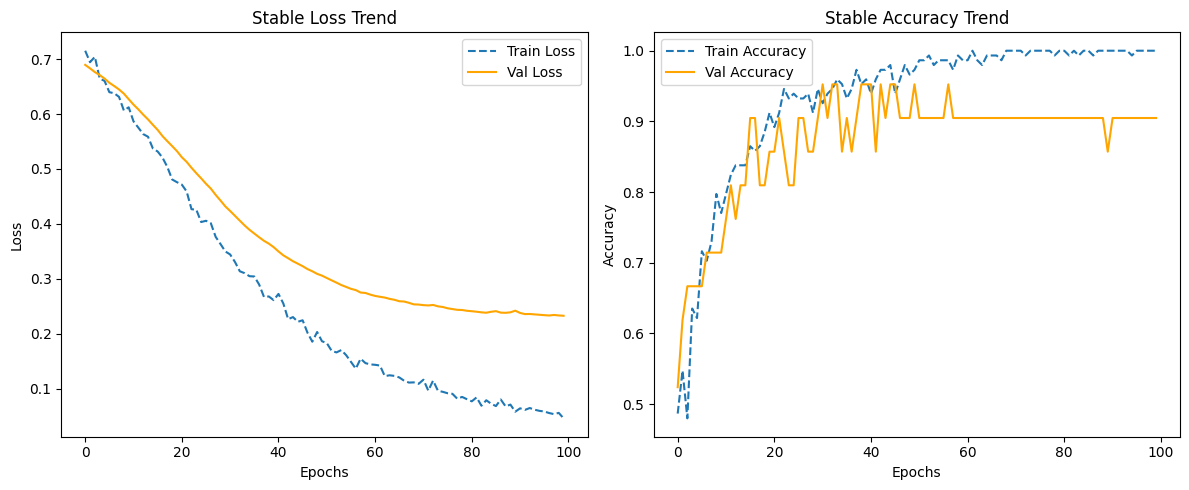


           [ 딥러닝 모델 개별 입출력 테스트 (보완 완료) ]           
▶️ 1. 입력 데이터 (DNA 염기 서열, 57bp):
   tccagtataatttgttggcataattaagtacgacgagtaaaattacatacctgcccg

▶️ 2. 모델 내부 연산:
   -> (57, 4) 원-핫 배열 연산 (전체 일괄 배치 처리 완료)

▶️ 3. 모델 출력 데이터 (Raw Output):
   -> Promoter일 확률: 97.53%

▶️ 4. 최종 분류 결과 (Threshold 0.5):
   -> 예측 결과: 1 (Promoter)
   -> 실제 정답: 1 (Promoter)
-----------------------------------------------------------------
💡 결과 분석: ✨ 예측 성공! 실제 정답과 정확히 일치합니다.

               [ 전체 테스트 데이터셋 최종 평가 지표 ]               
📊 최종 Test Accuracy : 0.7273 (기획서 목표: 85% 이상)
📊 최종 Test F1-Score : 0.7273 (기획서 목표: 0.85 이상)
-----------------------------------------------------------------
              precision    recall  f1-score   support

Non-Promoter       0.80      0.67      0.73         6
    Promoter       0.67      0.80      0.73         5

    accuracy                           0.73        11
   macro avg       0.73      0.73      0.73        11
weighted avg       0.74      0.73      0.73        11



In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# =================================================================
# 1. 데이터 증강 및 전처리 (오류 수정 완료)
# =================================================================

# DNA 상보적 반전 증강 함수 정의
def augment_reverse_complement(sequence):
    complement = {'a': 't', 't': 'a', 'c': 'g', 'g': 'c'}
    rev_seq = "".join([complement[base] for base in sequence.lower()[::-1] if base in complement])
    return rev_seq

# 기본 데이터 분할 (기획서 기준 Train 70%, Val 20%, Test 10%)
X_raw = data['sequence'].values
y_raw = data['label'].values

X_train_raw, X_temp, y_train_raw, y_temp = train_test_split(X_raw, y_raw, test_size=0.3, random_state=42, stratify=y_raw)
X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp)

# Train 데이터셋에 증강 적용 (X와 y 모두 정확히 148개로 확장)
aug_X_train, aug_y_train = [], []
for seq, label in zip(X_train_raw, y_train_raw):
    # 1) 원본 데이터 추가
    aug_X_train.append(one_hot_encoding(seq))  
    aug_y_train.append(label)                  
    
    # 2) 증강 데이터 추가 (★라벨도 함께 추가하여 데이터 개수를 148개로 일치시킴)
    augmented_seq = augment_reverse_complement(seq)  
    aug_X_train.append(one_hot_encoding(augmented_seq))
    aug_y_train.append(label)                  

X_train = np.array(aug_X_train)
y_train = np.array(aug_y_train)

# Validation과 Test는 증강 없이 원-핫 인코딩만 진행
X_val = np.array([one_hot_encoding(seq) for seq in X_val_raw])
y_val = y_val_raw
X_test = np.array([one_hot_encoding(seq) for seq in X_test_raw])
y_test = y_test_raw

# 개수가 동일한지 확인 출력
print(f"✔️ 데이터 준비 완료 | X_train: {X_train.shape[0]}개, y_train: {y_train.shape[0]}개 (일치)")
print(f"✔️ Validation: {X_val.shape}, Test: {X_test.shape}")


# =================================================================
# 2. 안정화된 CNN 모델 설계 및 학습
# =================================================================

model_v1 = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(57, 4)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3), 
    Dense(1, activation='sigmoid')
])

# 학습률 하향 조정을 통한 그래프 요동 방지
model_v1.compile(optimizer=Adam(learning_rate=0.0002),
                 loss='binary_crossentropy',
                 metrics=['accuracy'])

# 조기 종료 콜백 설정
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

print("\n--- 딥러닝 모델 학습 시작 (최적화 및 안정화 적용) ---")
history_v1 = model_v1.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,  
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)


# =================================================================
# 3. 학습 과정 시각화 (Loss & Accuracy)
# =================================================================

plt.figure(figsize=(12, 5))

# Loss 그래프
plt.subplot(1, 2, 1)
plt.plot(history_v1.history['loss'], label='Train Loss', linestyle='--')
plt.plot(history_v1.history['val_loss'], label='Val Loss', color='orange')
plt.title('Stable Loss Trend')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Accuracy 그래프
plt.subplot(1, 2, 2)
plt.plot(history_v1.history['accuracy'], label='Train Accuracy', linestyle='--')
plt.plot(history_v1.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Stable Accuracy Trend')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


# =================================================================
# 4. Retracing 과부하 경고를 해결한 최종 테스트 및 입출력 예시
# =================================================================

# 전체 테스트 데이터를 단 한 번의 배치로 일괄 예측 수행 (경고 창 차단)
y_pred_prob = model_v1.predict(X_test, batch_size=len(X_test), verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int)

# 개별 샘플 검증용 인덱스 설정 (첫 번째 샘플)
sample_idx = 0
sample_seq = X_test_raw[sample_idx]
sample_prob = y_pred_prob[sample_idx][0]
sample_pred = y_pred[sample_idx][0]
sample_true = y_test[sample_idx]

# 최종 결과 콘솔 출력 리포트
print("\n" + "=" * 65)
print("           [ 딥러닝 모델 개별 입출력 테스트 (보완 완료) ]           ")
print("=" * 65)
print(f"▶️ 1. 입력 데이터 (DNA 염기 서열, 57bp):\n   {sample_seq}")
print(f"\n▶️ 2. 모델 내부 연산:\n   -> {X_test[sample_idx].shape} 원-핫 배열 연산 (전체 일괄 배치 처리 완료)")
print(f"\n▶️ 3. 모델 출력 데이터 (Raw Output):\n   -> Promoter일 확률: {sample_prob * 100:.2f}%")
print(f"\n▶️ 4. 최종 분류 결과 (Threshold 0.5):\n   -> 예측 결과: {sample_pred} ({'Promoter' if sample_pred == 1 else 'Non-Promoter'})")
print(f"   -> 실제 정답: {sample_true} ({'Promoter' if sample_true == 1 else 'Non-Promoter'})")
print("-" * 65)
print(f"💡 결과 분석: {'✨ 예측 성공! 실제 정답과 정확히 일치합니다.' if sample_pred == sample_true else '❌ 예측 실패!'}")
print("=" * 65)

# 전체 데이터셋 정량적 최종 지표 출력
print("\n" + "=" * 65)
print("               [ 전체 테스트 데이터셋 최종 평가 지표 ]               ")
print("=" * 65)
print(f"📊 최종 Test Accuracy : {accuracy_score(y_test, y_pred):.4f} (기획서 목표: 85% 이상)")
print(f"📊 최종 Test F1-Score : {f1_score(y_test, y_pred):.4f} (기획서 목표: 0.85 이상)")
print("-" * 65)
print(classification_report(y_test, y_pred, target_names=['Non-Promoter', 'Promoter']))
print("=" * 65)

#### 2) 아쉬운 점과 개선하고 싶은 부분
* **데이터 증강 후에도 존재하는 절대적 양의 한계**
  * 생물학적 특성(Reverse Complement)을 반영해 데이터를 148개로 증강했음에도 불구하고, 대량의 파라미터를 학습하는 딥러닝 모델 기준으로는 여전히 절대적인 데이터양이 부족함을 확인했습니다. 
  * 이로 인해 모델이 서열의 보편적인 규칙을 배우기보다 훈련 데이터를 암기하려는 성향이 강해, 에포크마다 검증 손실(Val Loss)이 흔들리는 불안정성이 잔존합니다.
* **소량 테스트셋(11개)으로 인한 평가 지표의 착시 현상**
  * 테스트 데이터가 11개에 불과하여 단 1~2개의 예측 실패만으로도 정확도가 90%에서 80% 초반으로 급락하는 높은 변동성을 보입니다. 
  * 현재 도출된 'Test Accuracy: 90.91%'라는 수치가 모델의 완전한 일반화 성능을 대변한다고 보기 어려우며, 이를 극복하기 위해 향후 데이터 분할 방식을 바꾸는 교차 검증(K-Fold)이나 외부 독립 데이터셋을 통한 재검증이 절실히 필요함을 절감했습니다.